In [721]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Rectangle
from collections import defaultdict
from datetime import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import json
import os


In [722]:
data_dir = "./data"

processed_dir = os.path.join(data_dir, "processed")
pretest_path = os.path.join(processed_dir, "pretest.csv")
postest_path = os.path.join(processed_dir, "postest.csv")
gameplay_path = os.path.join(processed_dir, "gameplay.ndjson")


In [723]:
pretest_df = pd.read_csv(pretest_path, encoding="utf-8")
postest_df = pd.read_csv(postest_path, encoding="utf-8")


In [724]:
def describe_demographics(pre_df: pd.DataFrame):
    print(f"N: {pre_df['age'].count()}")
    print(f"Mean ± SD: {pre_df['age'].mean():.1f} ± {pre_df['age'].std():.1f}")
    print(f"Median: {pre_df['age'].median():.1f}")
    print(f"Range: {pre_df['age'].min()}-{pre_df['age'].max()}")

    gender = pre_df["gender"].value_counts()
    gender_pct = pre_df["gender"].value_counts(normalize=True) * 100
    display(pd.concat([gender, gender_pct.round(1)], axis=1, keys=["n", "%"]))

    education = pre_df["education_level"].value_counts()
    education_pct = pre_df["education_level"].value_counts(normalize=True) * 100
    display(pd.concat([education, education_pct.round(1)], axis=1, keys=["n", "%"]))
    
    study = pre_df["study_area"].value_counts()
    study_pct = pre_df["study_area"].value_counts(normalize=True) * 100
    display(pd.concat([study, study_pct.round(1)], axis=1, keys=["n", "%"]))


In [725]:
describe_demographics(pretest_df)


N: 2
Mean ± SD: 23.0 ± 1.4
Median: 23.0
Range: 22-24


,n,%
gender,,
Femenino,2,100.0


,n,%
education_level,,
Estudios universitarios,2,100.0


,n,%
study_area,,
Ciencias de la Salud,1,50.0
Ciencias Sociales,1,50.0


In [726]:
dialogue_cols = [
    "dialogue_advance_only",
    "dialogue_predefined_options",
    "dialogue_free_text",
    "dialogue_hybrid",
]

dialogue_diff = (
    pretest_df[["access_code"] + dialogue_cols]
    .merge(
        postest_df[["access_code"] + dialogue_cols],
        on="access_code",
        suffixes=("_pre", "_post"),
    )
)

for col in dialogue_cols:
    dialogue_diff[f"{col}_diff"] = dialogue_diff[f"{col}_post"] - dialogue_diff[f"{col}_pre"]

dialogue_diff = dialogue_diff[["access_code"] + [f"{col}_diff" for col in dialogue_cols]]

display(dialogue_diff)


,access_code,dialogue_advance_only_diff,dialogue_predefined_options_diff,dialogue_free_text_diff,dialogue_hybrid_diff
0,22_tstp,0,0,-1,1
1,22_vezs,0,0,0,0


In [727]:
def plot_dialogue_changes(pre_df: pd.DataFrame, post_df: pd.DataFrame):
    cols = [
        "dialogue_advance_only",
        "dialogue_predefined_options",
        "dialogue_free_text",
        "dialogue_hybrid",
    ]
    
    df = pre_df.merge(
        post_df,
        on="access_code",
        suffixes=("_pre", "_post"),
    )

    # Calcular cambios
    changes = pd.DataFrame({
        col: df[f"{col}_post"] - df[f"{col}_pre"]
        for col in cols
    })

    fig, ax = plt.subplots(figsize=(9, 5))

    # Boxplot
    # Línea central -> mediana
    # Caja -> intervalo intercuartílico (Q1-Q3), es decir, el 50% de los datos
    # Bigotes -> rango de los datos
    sns.boxplot(
        data=changes,
        showfliers=False,
        width=0.5,
        color="white",
        ax=ax,
    )

    # Participantes individuales
    sns.swarmplot(
        data=changes,
        size=7,
        ax=ax,
    )

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)

    ax.set_ylabel("Change (Post - Pre)")
    ax.set_xlabel("")
    ax.set_ylim(-4.5, 4.5)

    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


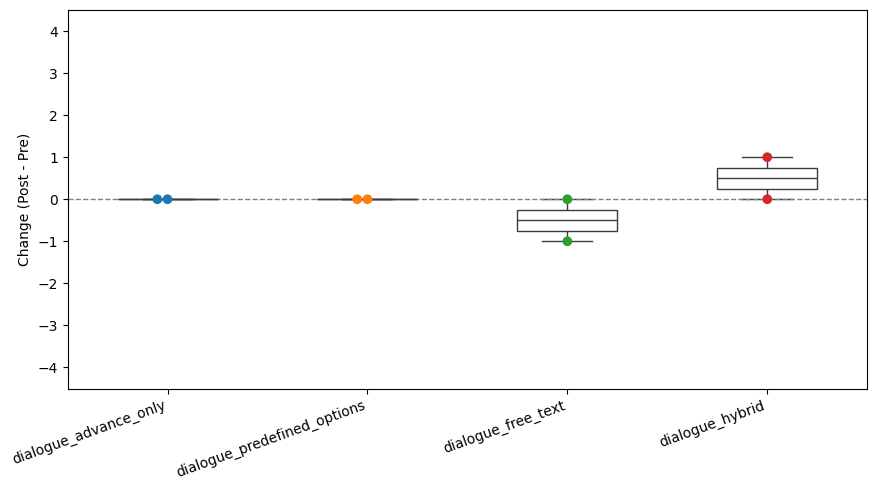

In [728]:
plot_dialogue_changes(pretest_df, postest_df)


In [729]:
# To calculate the SUS score, first sum the score contributions from each item. Each item's
# score contribution will range from 0 to 4. For items 1,3,5,7,and 9 the score contribution is the
# scale position minus 1. For items 2,4,6,8 and 10, the contribution is 5 minus the scale position.
# Multiply the sum of the scores by 2.5 to obtain the overall value of SU.
def calculate_sus(row: pd.Series):
    items = [
        row["sus_use_frequently"],
        row["sus_unnecessarily_complex"],
        row["sus_easy_to_use"],
        row["sus_need_technical_support"],
        row["sus_well_integrated"],
        row["sus_too_much_inconsistency"],
        row["sus_easy_to_learn"],
        row["sus_cumbersome"],
        row["sus_confident"],
        row["sus_need_to_learn"],
    ]

    score = 0

    for i, response in enumerate(items, start=1):
        # Items impares
        if i % 2 == 1:
            score += response - 1
        # Item pares
        else:
            score += 5 - response

    return score * 2.5


In [730]:
postest_df["sus_score"] = postest_df.apply(calculate_sus, axis=1)


In [731]:
display(postest_df["sus_score"])


0    60.0
1    85.0
Name: sus_score, dtype: float64

In [732]:
print(f"Mean SUS: {postest_df['sus_score'].mean():.1f}")
print(f"Median SUS: {postest_df['sus_score'].median():.1f}")
print(f"SD: {postest_df['sus_score'].std():.1f}")


Mean SUS: 72.5
Median SUS: 72.5
SD: 17.7


In [733]:
def plot_sus_score(post_df: pd.DataFrame):

    scores = post_df["sus_score"].dropna()

    mean_sus = scores.mean()

    fig, ax = plt.subplots(
        figsize=(11, 3.5),
        dpi=120
    )

    bar_y = 0
    bar_height = 0.18

    regions = [
        (0, 50, "#d73027", "Not acceptable"),
        (50, 70, "#fee08b", "Marginal"),
        (70, 100, "#1a9850", "Acceptable"),
    ]

    for start, end, color, label in regions:
        ax.add_patch(
            Rectangle(
                (start, bar_y - bar_height / 2),
                end-start,
                bar_height,
                facecolor=color,
                alpha=0.45,
                edgecolor="none"
            )
        )

        ax.text(
            (start+end)/2,
            0.12,
            label,
            ha="center",
            fontsize=12,
            fontweight="bold"
        )


    # Separadores
    for x in [50, 70]:
        ax.vlines(
            x,
            -bar_height/2,
            bar_height/2,
            color="white",
            linewidth=2
        )

    # Participantes
    ax.scatter(
        scores,
        np.zeros(len(scores)),
        s=75,
        facecolor="white",
        edgecolor="#222222",
        linewidth=1,
        alpha=0.9,
        zorder=3,
        label=f"Participants (n={len(scores)})"
    )

    # Media
    ax.scatter(
        mean_sus,
        0,
        marker="D",
        s=130,
        color="#111111",
        zorder=4,
        label=f"Mean = {mean_sus:.1f}"
    )


    # Escala inferior
    scale_y = -0.12

    ax.hlines(
        scale_y,
        0,
        100,
        color="black",
        linewidth=1
    )

    for x in range(0, 101, 10):
        ax.vlines(
            x,
            scale_y,
            scale_y+0.03,
            color="black",
            linewidth=1
        )

        ax.text(
            x,
            scale_y-0.04,
            str(x),
            ha="center",
            fontsize=11
        )
    
    ax.set_xlim(0,100)
    ax.set_ylim(-0.20,0.20)

    ax.set_yticks([])
    ax.set_xticks([])

    ax.set_title(
        "System Usability Scale (SUS)",
        fontsize=14,
        fontweight="bold",
        pad=-5
    )

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.01,0.5),
        frameon=False,
        fontsize=13
    )

    plt.tight_layout()

    plt.show()


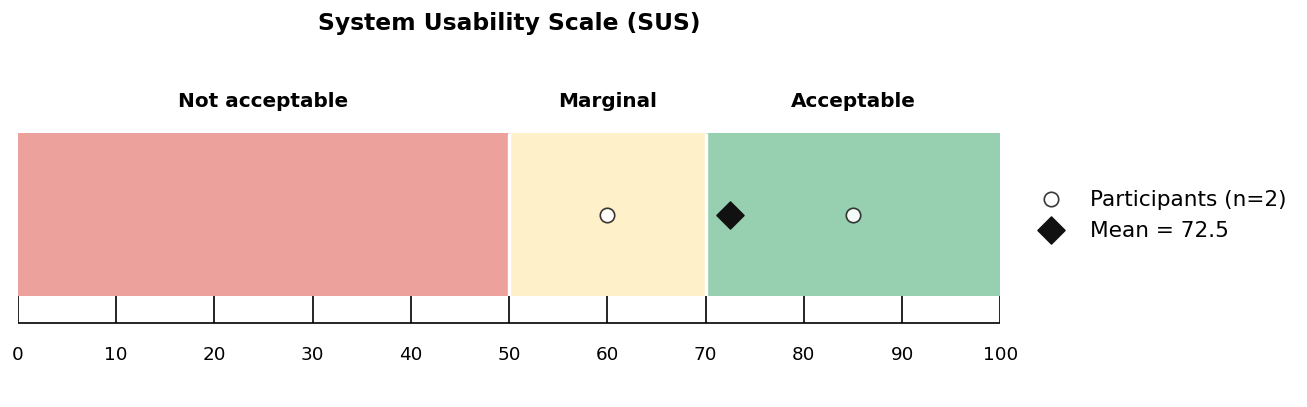

In [734]:
plot_sus_score(postest_df)


In [735]:
def plot_likert_stacked(post_df: pd.DataFrame, cols: list[str], title: str = "Likert evaluation"):
    likert_values = [1, 2, 3, 4, 5]

    colors = [
        "#d73027",
        "#fc8d59",
        "#fee08b",
        "#91cf60",
        "#1a9850",
    ]

    counts = pd.DataFrame()

    for col in cols:
        counts[col] = post_df[col].value_counts().reindex(likert_values, fill_value=0)

    counts = counts.T

    fig, ax = plt.subplots(figsize=(9, 4))

    left = [0] * len(counts)

    for value, color in zip(likert_values, colors):
        values = counts[value].tolist()

        ax.barh(
            counts.index,
            values,
            left=left,
            label=str(value),
            color=color,
        )

        for i in range(len(left)):
            left[i] += values[i]

    ax.set_xlabel("Number of participants")
    ax.set_xlim(0, len(post_df))
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax.legend(
        title="Likert response",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
    )

    ax.set_title(title)

    plt.tight_layout()
    plt.show()


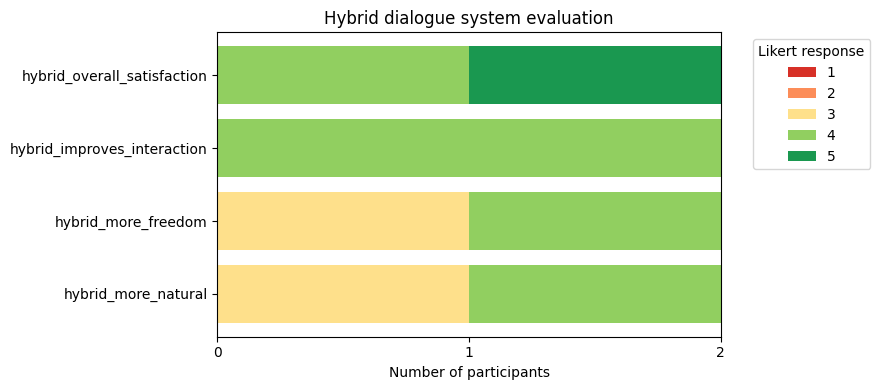

In [736]:
cols = [
    "hybrid_more_natural",
    "hybrid_more_freedom",
    "hybrid_improves_interaction",
    "hybrid_overall_satisfaction",
]

plot_likert_stacked(postest_df, cols, "Hybrid dialogue system evaluation")


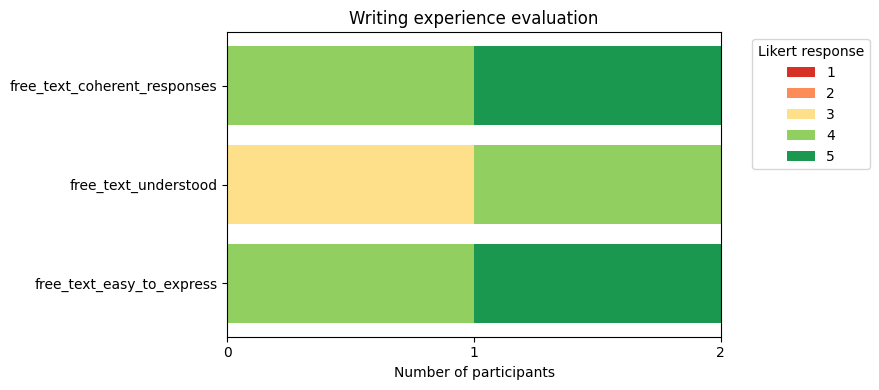

In [737]:
cols = [
    "free_text_easy_to_express",
    "free_text_understood",
    "free_text_coherent_responses"
]

plot_likert_stacked(postest_df, cols, "Writing experience evaluation")


In [738]:
with open(gameplay_path, "r", encoding="utf-8") as f:
    records = [json.loads(line) for line in f]

print(f"Original records: {len(records)}")


Original records: 103


In [739]:
NODE_EXTENSION = "https://w3id.org/xapi/seriousgame/extensions/Node"

START_EVENT = "https://w3id.org/xapi/lab/activity-types/story-node/ThoughtBoxStart"
END_EVENT = "https://w3id.org/xapi/lab/activity-types/story-node/ThoughtBoxEnd"

# Comienzos para cada (usuario, nodo)
pending_starts = defaultdict(list)

# Duraciones para cada (usuario, nodo)
durations = defaultdict(list)

matches = defaultdict(list)

for record in records:
    event = record.get("object", {}).get("id")
    user = record.get("actor", {}).get("account", {}).get("name")
    node = record.get("result", {}).get("extensions", {}).get(NODE_EXTENSION)

    timestamp = datetime.fromisoformat(record["timestamp"].replace("Z", "+00:00"))

    key = (user, node)

    if event == START_EVENT:
        pending_starts[key].append(timestamp)

    elif event == END_EVENT:
        if pending_starts[key]:
            start = pending_starts[key].pop(0)
            duration = (timestamp - start).total_seconds()

            durations[key].append(duration)
            matches[key].append((start, timestamp, duration))

print("Average ThoughtBox duration per user/node:")
for (user, node), values in durations.items():
    avg = sum(values) / len(values)
    print(f"{user:10} | {node:40} | count={len(values)}) | avg={avg:.4f} s")

print("\nLong durations (>60 s):")
for (user, node), pairs in matches.items():
    for start, end, duration in pairs:
        if duration > 60:
            print(
                f"User : {user}\n"
                f"Node : {node}\n"
                f"Start: {start.isoformat()}\n"
                f"End  : {end.isoformat()}\n"
                f"Δt   : {duration:.4f} s\n"
            )


Average ThoughtBox duration per user/node:
vezs       | Scene1Classroom.part2.thanks_similarity  | count=2) | avg=0.0020 s
vezs       | Computer.computer1.choices_similarity    | count=1) | avg=0.0020 s
vezs       | Computer.computer2.root                  | count=1) | avg=0.0010 s
vezs       | Computer.computer.choices2_similarity    | count=3) | avg=0.0010 s
vezs       | Scene2Break.part2.choice_similarity      | count=1) | avg=0.0020 s
vezs       | Scene3Bedroom.main.choices_similarity    | count=3) | avg=0.0017 s
vezs       | Scene4Backyard.mainConversation.choices_similarity | count=1) | avg=0.0010 s
vezs       | Scene4Garage.phone1.root                 | count=1) | avg=0.0010 s
vezs       | Scene4Garage.photo.choices_similarity    | count=2) | avg=0.0015 s
vezs       | Scene4Bedroom.phone.root                 | count=2) | avg=0.0020 s
vezs       | Scene6LunchRouteB.phone.root             | count=3) | avg=0.0020 s
tstp       | Scene1Classroom.part2.thanks_similarity  | count=1) | 

In [740]:
node_user_avgs = defaultdict(list)

for (user, node), values in durations.items():
    node_user_avgs[node].append(sum(values) / len(values))

print("\nAverage ThoughtBox duration per node (averaging users):")

nodes = []
averages = []

for node, user_avgs in sorted(node_user_avgs.items()):
    avg = sum(user_avgs) / len(user_avgs)

    print(
        f"{node:40} | "
        f"users={len(user_avgs):2d} | "
        f"avg={avg:.4f} s"
    )

    nodes.append(node)
    averages.append(avg)



Average ThoughtBox duration per node (averaging users):
Computer.computer.choices2_similarity    | users= 2 | avg=0.0018 s
Computer.computer1.choices_similarity    | users= 2 | avg=0.0020 s
Computer.computer2.root                  | users= 2 | avg=0.0010 s
Scene1Classroom.part2.thanks_similarity  | users= 2 | avg=0.0025 s
Scene2Break.part2.choice_similarity      | users= 2 | avg=0.0020 s
Scene3Bedroom.main.choices_similarity    | users= 2 | avg=0.0018 s
Scene4Backyard.mainConversation.choices_similarity | users= 2 | avg=0.0025 s
Scene4Bedroom.phone.root                 | users= 2 | avg=0.0020 s
Scene4Garage.phone1.root                 | users= 1 | avg=0.0010 s
Scene4Garage.photo.choices_similarity    | users= 2 | avg=0.0013 s
Scene6BedroomRouteA1.phone.choices1_similarity | users= 1 | avg=0.0020 s
Scene6LunchRouteB.phone.root             | users= 1 | avg=0.0020 s


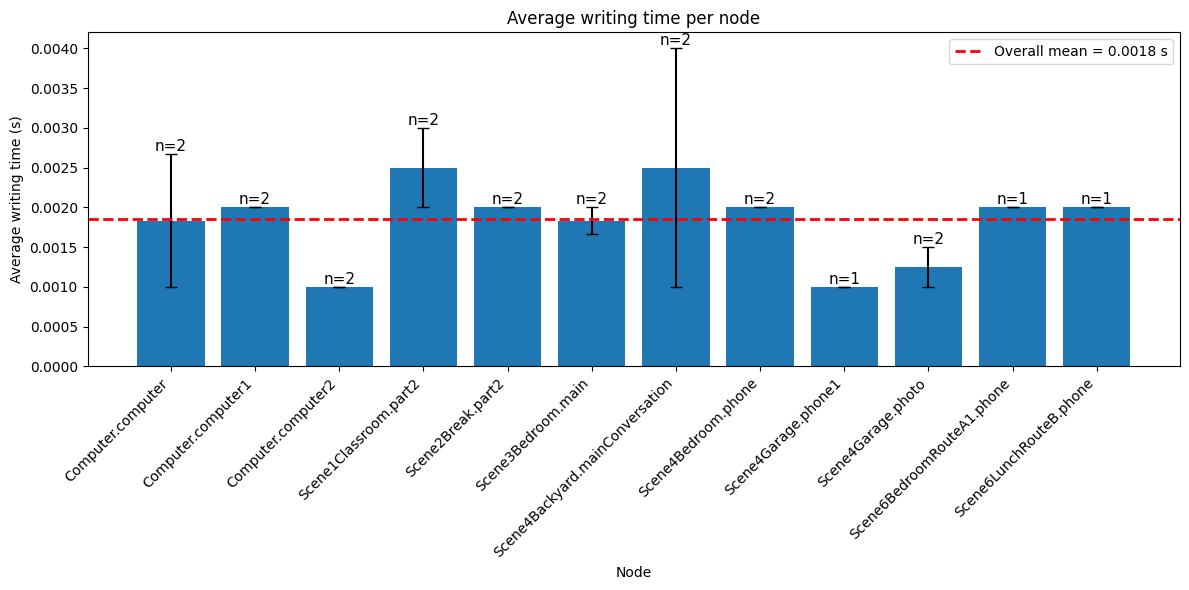

In [741]:
labels = [".".join(node.split(".")[:2]) for node in nodes]

items = sorted(node_user_avgs.items())

labels = []
means = []
sems = []
counts = []

for node, user_avgs in items:
    n_users = len(user_avgs)

    # Media de los usuarios para el nodo
    mean = np.mean(user_avgs)
    # Standard Error of the Mean (SEM)
    sem = np.std(user_avgs, ddof=1) / np.sqrt(n_users) if len(user_avgs) > 1 else 0

    labels.append(".".join(node.split(".")[:2]))
    means.append(mean)
    sems.append(sem)
    counts.append(n_users)

# Media ponderada en función del número de usuarios
overall_mean = np.average(means, weights=counts)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    labels, 
    means, 
    yerr=sems, 
    capsize=4
)

plt.axhline(
    overall_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Overall mean = {overall_mean:.4f} s",
)

# Número de usuarios encima de cada barra
for bar, n_users, sem in zip(bars, counts, sems):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + sem,
        f"n={n_users}",
        ha="center",
        va="bottom",
        fontsize=11,
    )

plt.xticks(rotation=45, ha="right")
plt.xlabel("Node")
plt.ylabel("Average writing time (s)")
plt.title("Average writing time per node")
plt.legend()
plt.tight_layout()
plt.show()
